# Proyecto Final Equipo 7 🧸

# Título del Proyecto: Estatura - Distribución Normal y Comparación de Medias

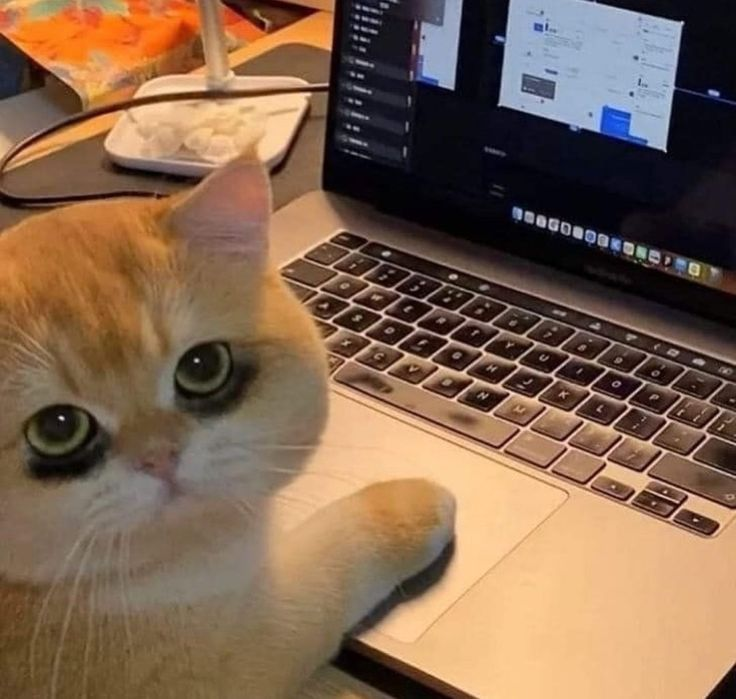


# Integrantes:

## ✦ Misael Saúl Avila López

## ✦ Diego López Tafoya

## ✦ Gustavo Eduardo Gómez Godínez

## ✦ Oscar Darío Hernández Cruz

## ✦ Estefany Abigail Valdés Cambero

# Introducción

El presente proyecto busca hacer uso de distintas herramientas estadísticas para resolver un caso práctico de análisis de distribución normal.

Mediante la obtención de datos obtenidos de National Health and Nutrition Examination Survey (NHANES), se buscará dar respuesta a dos preguntas principales que surgen al tomar como objeto de estudio las estaturas extraídas de nuestro conjunto de datos, estas preguntas son: ¿Siguen las estaturas de la población una distribución normal? y, ¿En la estatura media entre hombres y mujeres existe una diferencia significativa?

## Obtención de los datos

Para la obtención de los datos que servirán como base para este proyecto, se utilizó el archivo csv que podemos encontar en la siguiente liga:
[NHANES 2009-2918](https://drive.google.com/file/d/1i7ezKxKXYgzjDWofbOUEp_u81N7AfQeD/view?usp=sharing) , el cual cuenta con distintos datos registrados de una población como lo son peso, altura, IMC, género, edad, entre otros. Para nuestro caso de estudio unicamente nos enfocaremos en el registro de la altura de estos individuos.

Para poder llevar a cabo el proyecto, se hará uso de Python puesto que esta herramienta nos será útil para llevar a cabo los procesos estadísticos de manera más eficiente, ya que se trabajará con estimación de $\mu$ y $\sigma$ por máxima verosimilitud, pruebas de normalidad y prueba t para dos muestras independientes.

Comenzamos por identificar y hacer uso de aquellas librerías que no serán de apoyo para las pruebas estadísticas que realizaremos.

In [ ]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from scipy.stats import norm, t

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

Una vez que ya se hizo la identificación de las librerías que serán de apoyo en nuestro análisis, hay que realizar la carga de la base de datos que obtuvimos de NHANES para poder trabajar con ella.

In [ ]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/OscarDario/Proyecto_Modulo_II/main/NHANES_2009_2018.csv')

print('Tamaño del dataset:', df_raw.shape)
print('Tipos de datos:')
print(df_raw.dtypes)
df_raw.head()

Tamaño del dataset: (47652, 10)
Tipos de datos:
ID                        float64
Peso                      float64
Altura                    float64
IMC                       float64
Circunferencia_Cintura    float64
Genero                    float64
Edad                      float64
Raza_V1                   float64
Ciclo                       int64
Raza_V2                   float64
dtype: object


,ID,Peso,Altura,IMC,Circunferencia_Cintura,Genero,Edad,Raza_V1,Ciclo,Raza_V2
0,51624.0,87.4,164.7,32.22,100.4,1.0,34.0,3.0,2009,NaN
1,51625.0,17.0,105.4,15.30,49.0,1.0,4.0,5.0,2009,NaN
2,51626.0,72.3,181.3,22.00,74.7,1.0,16.0,4.0,2009,NaN
3,51627.0,39.8,147.8,18.22,63.0,1.0,10.0,4.0,2009,NaN
4,51628.0,116.8,166.0,42.39,118.2,2.0,60.0,4.0,2009,NaN


Ahora, recordemos que nuestro objeto de análisis es la columna que corresponde a las alturas de los individuos de los que se tomaron los datos, hay que tomar en cuenta que dentro de nuestra base de datos, es decir, dentro del archivo que obtuvimos de NHANES también se encuentran celdas vacías o nulas las cuales es importante identificar pues influye en el resultado que obtendremos.

In [ ]:
print('Valores nulos por columna:')
print(df_raw.isnull().sum())
print(f"\nNulos en Altura: {df_raw['Altura'].isnull().sum()} "
      f"({df_raw['Altura'].isnull().mean()*100:.1f}%)")

Valores nulos por columna:
ID                            0
Peso                        499
Altura                     3765
IMC                        3822
Circunferencia_Cintura     5900
Genero                        0
Edad                          0
Raza_V1                       0
Ciclo                         0
Raza_V2                   10253
dtype: int64

Nulos en Altura: 3765 (7.9%)


Ahora, es necesario eliminar estos datos que se encuentran incompletos y que no aportarán información relevante para nuestras pruebas estadísticas

In [ ]:
# Eliminar filas sin Altura, Genero o Edad
df = df_raw.dropna(subset=['Altura', 'Genero', 'Edad']).copy()

# Renombrar y codificar género (1=Hombre, 2=Mujer)
df['Sexo'] = df['Genero'].map({1.0: 'Hombre', 2.0: 'Mujer'})
df = df.drop(columns='Genero')

print(f'Filas tras limpieza: {len(df):,}')
df.head()

Filas tras limpieza: 43,887


,ID,Peso,Altura,IMC,Circunferencia_Cintura,Edad,Raza_V1,Ciclo,Raza_V2,Sexo
0,51624.0,87.4,164.7,32.22,100.4,34.0,3.0,2009,NaN,Hombre
1,51625.0,17.0,105.4,15.30,49.0,4.0,5.0,2009,NaN,Hombre
2,51626.0,72.3,181.3,22.00,74.7,16.0,4.0,2009,NaN,Hombre
3,51627.0,39.8,147.8,18.22,63.0,10.0,4.0,2009,NaN,Hombre
4,51628.0,116.8,166.0,42.39,118.2,60.0,4.0,2009,NaN,Mujer


## Análisis estadístico

Ahora, al tener ya filtrados los datos que usaremos para el presente trabajo, recordemos que nuestro principal objetivo es dar respuesta a las dos preguntas mencionadas anteriormente en la introducción.

Una de las preguntas es: ¿Siguen las alturas una distribución normal?

Para dar respuesta a este cuestionamiento, recordemos que por el Teorema Central del Límite al tener una muestra grande ($\geq 30$) de nuestra población estudiada, podemos suponer que nuestros datos siguen una distribución normal $X \sim (\mu, \sigma^2)$.

Para esto, daremos una estimación para $\mu$ y $\sigma^2$ por MLE, es decir, por máxima verosimilitud.



Recordemos que nuestra función de verosimilitud viene dada por $L(\theta, X)$ donde $\theta = (\mu,\sigma^2)$ y $X=(x_1,x_2,...,x_n)$ y al trabajar con una distribución normal tenemos que $$L(\theta, X)=\prod_{i=1}^{n}f(x_i,\mu,\sigma^2)$$
$$=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{1}{2\sigma^2}(x_i-\mu)^2}$$
$$=(\frac{1}{\sqrt{2\pi\sigma^2}})^n \prod_{i=1}^{n}e^{-\frac{1}{2\sigma^2}(x_i-\mu)^2}$$

$$=(\frac{1}{\sqrt{2\pi\sigma^2}})^n e^{-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2}$$

Ahora aplicamos log-verosimilitud:

$$\ell(L(\theta, X)) = \ell((\frac{1}{\sqrt{2\pi\sigma^2}})^n e^{-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2})$$
$$= \ell((\frac{1}{2\pi\sigma^2})^{\frac{n}{2}})+\ell(e^{-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2})$$
$$= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(X_i - \mu)^2$$

Derivando respecto a $\mu$ y $\sigma^2$ e igualando a cero se obtienen los estimadores de máxima verosimilitud:

$$\hat{\mu}_{\text{EMV}} = \frac{1}{n}\sum_{i=1}^{n} X_i = \bar{X}, \qquad \hat{\sigma}^2_{\text{EMV}} = \frac{1}{n}\sum_{i=1}^{n}(X_i - \bar{X})^2$$

> **Nota:** $\hat{\sigma}^2_{\text{EMV}}$ es **sesgado**: su esperanza es $\mathbb{E}[\hat{\sigma}^2_{\text{EMV}}] = \frac{n-1}{n}\sigma^2$, no $\sigma^2$. Por eso, para construir intervalos de confianza usaremos la varianza muestral **insesgada** $S^2 = \frac{1}{n-1}\sum(X_i - \bar{X})^2$ (corrección de Bessel).

Ahora, aplicaremos esta teoría a python

Una vez que ya contamos con una base de datos limpia y preparada para trabajar, procederemos a calcular los estimadores de máxima verosimilitud para nuestra variable de interés, que en este caso corresponde a la altura de los individuos.

Primero obtendremos el tamaño de la muestra y posteriormente calcularemos la media muestral, ya que esta funciona como un buen estimador de la media poblacional. Después, calcularemos la varianza y la desviación estándar utilizando el método de máxima verosimilitud, donde la varianza se obtiene dividiendo entre n.

Además, también calcularemos la versión insesgada de la varianza y desviación estándar aplicando la corrección de Bessel, es decir, dividiendo entre n−1, con el objetivo de comparar ambos resultados y utilizar posteriormente estas medidas en nuestras pruebas e intervalos de confianza.

In [ ]:
datos = df['Altura'].values
n = len(datos)

# EMV calculados manualmente con la fórmula (divide entre n, sin Bessel)
mu_mle     = np.sum(datos) / n
sigma2_mle = np.sum((datos - mu_mle)**2) / n
sigma_mle  = np.sqrt(sigma2_mle)

# Versión insesgada (corrección de Bessel) para uso posterior en IC
s2 = np.sum((datos - mu_mle)**2) / (n - 1)
s  = np.sqrt(s2)

print(f'n = {n:,}')
print(f'EMV       μ̂  = {mu_mle:.4f} cm')
print(f'EMV       σ̂² = {sigma2_mle:.4f} cm²  (sesgado)')
print(f'EMV       σ̂  = {sigma_mle:.4f} cm')
print(f'Insesgado S² = {s2:.4f} cm²  (Bessel)')
print(f'Insesgado S  = {s:.4f} cm')

n = 43,887
EMV       μ̂  = 155.8886 cm
EMV       σ̂² = 536.5594 cm²  (sesgado)
EMV       σ̂  = 23.1638 cm
Insesgado S² = 536.5716 cm²  (Bessel)
Insesgado S  = 23.1640 cm


Con los estimadores de máxima verosimilitud ya calculados, realizaremos una representación gráfica de la distribución de las estaturas presentes en nuestra muestra.

Primero construiremos un histograma para observar cómo se distribuyen los datos de altura y analizar visualmente su comportamiento. Posteriormente, sobre el mismo gráfico agregaremos una curva de distribución normal ajustada utilizando los parámetros estimados anteriormente, es decir, la media y la desviación estándar obtenidas mediante máxima verosimilitud.

Con esta comparación podremos observar qué tan bien se ajustan los datos reales a una distribución normal y analizar si el comportamiento de las estaturas sigue aproximadamente este modelo probabilístico.

A partir de la gráfica podemos observar que las estaturas siguen una distribución aproximadamente normal, ya que la mayoría de los datos se concentran alrededor de la media y disminuyen conforme nos alejamos de ella.

Sin embargo, el ajuste no es perfecto, pues el histograma presenta cierta asimetría y diferencias respecto a la curva normal ajustada. Aun así, la distribución normal representa de manera razonable el comportamiento general de las estaturas en la muestra.

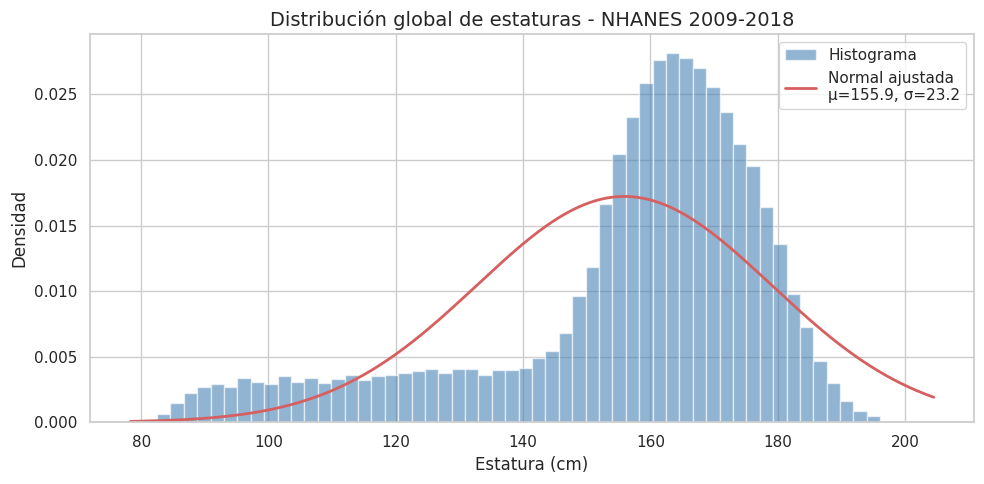

In [ ]:
# Histograma con la curva normal ajustada usando los EMV
fig, ax = plt.subplots()
ax.hist(datos, bins=60, density=True, alpha=0.6, color='steelblue', label='Histograma')

x_plot = np.linspace(datos.min(), datos.max(), 300)
ax.plot(x_plot, norm.pdf(x_plot, loc=mu_mle, scale=sigma_mle), 'r-', lw=2,
        label=f'Normal ajustada\nμ={mu_mle:.1f}, σ={sigma_mle:.1f}')

ax.set_xlabel('Estatura (cm)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución global de estaturas - NHANES 2009-2018')
ax.legend()
plt.tight_layout()
plt.show()

A partir del boxplot podemos observar que la mayoría de las estaturas se concentran aproximadamente entre 150 y 170 cm, con una mediana cercana a los 160 cm.

Además, se identifican varios valores atípicos, principalmente en las estaturas más bajas, lo que indica la presencia de datos alejados del comportamiento central de la muestra. Esto también explica parte de la asimetría observada anteriormente en el histograma.

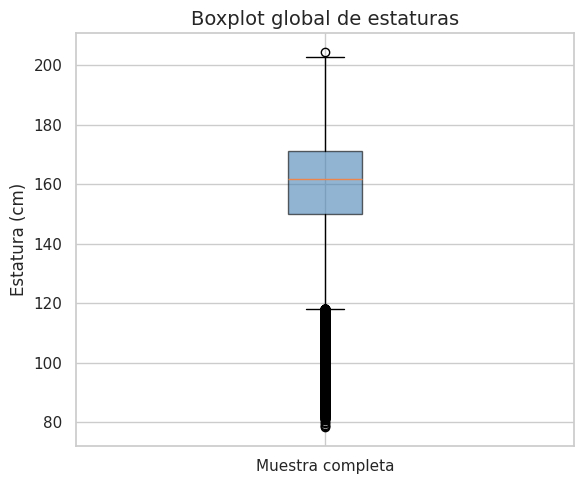

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(datos, vert=True, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Estatura (cm)')
ax.set_title('Boxplot global de estaturas')
ax.set_xticks([1])
ax.set_xticklabels(['Muestra completa'])
plt.tight_layout()
plt.show()

## Análisis por sexo

Se separan las estaturas de la muestra según el sexo de los individuos, obteniendo un conjunto de datos para hombres y otro para mujeres.

Posteriormente, se calcula el tamaño de cada grupo con el objetivo de realizar comparaciones estadísticas entre ambos conjuntos de datos en los siguientes análisis.

In [ ]:
hombres = df[df['Sexo'] == 'Hombre']['Altura'].values
mujeres = df[df['Sexo'] == 'Mujer']['Altura'].values

print(f'Hombres: n = {len(hombres):,}')
print(f'Mujeres: n = {len(mujeres):,}')

Hombres: n = 21,630
Mujeres: n = 22,257


En esta parte del análisis se calculan distintas medidas estadísticas para las estaturas de hombres y mujeres por separado. Primero se obtiene la media muestral, la varianza y la desviación estándar de cada grupo, con el objetivo de analizar su comportamiento y dispersión.

Posteriormente, se calcula el error estándar de la media y se construye un intervalo de confianza del 95% para la media poblacional utilizando la distribución t de Student, ya que se trabaja con la desviación estándar muestral.

A partir de los resultados obtenidos, se observa que, en promedio, los hombres presentan una estatura mayor que las mujeres. Además, ambos intervalos de confianza son bastante estrechos debido al gran tamaño de la muestra, lo que indica estimaciones precisas para la media poblacional.

In [ ]:
confianza = 0.95

for nombre, datos_g in [('Hombres', hombres), ('Mujeres', mujeres)]:
    n_g = len(datos_g)
    gl  = n_g - 1
    media_muestral = np.mean(datos_g)
    s2 = np.var(datos_g, ddof=1)              # varianza muestral
    s  = np.sqrt(s2)
    error_est = s / np.sqrt(n_g)              # error estándar de la media

    # IC para mu (sigma desconocida -> t de Student)
    intervalo = st.t.interval(confianza, gl, loc=media_muestral, scale=error_est)

    print(f' {nombre} (n = {n_g:,}) ')
    print(f'  Media muestral  : {media_muestral:.2f} cm')
    print(f'  Desv. est. (s)  : {s:.2f} cm')
    print(f'  Varianza (s²)   : {s2:.2f} cm²')
    print(f'  Error estándar  : {error_est:.4f} cm')
    print(f'  IC {confianza*100:.0f}% para μ: ({intervalo[0]:.2f}, {intervalo[1]:.2f})\n')

 Hombres (n = 21,630) 
  Media muestral  : 160.63 cm
  Desv. est. (s)  : 25.11 cm
  Varianza (s²)   : 630.44 cm²
  Error estándar  : 0.1707 cm
  IC 95% para μ: (160.29, 160.96)

 Mujeres (n = 22,257) 
  Media muestral  : 151.28 cm
  Desv. est. (s)  : 20.06 cm
  Varianza (s²)   : 402.35 cm²
  Error estándar  : 0.1345 cm
  IC 95% para μ: (151.02, 151.55)



Realizaremos una comparación gráfica de las estaturas entre hombres y mujeres. Para ello, construiremos histogramas por separado para cada grupo y posteriormente ajustaremos una curva de distribución normal utilizando los estimadores de máxima verosimilitud calculados para cada caso.

Con estas gráficas podremos comparar visualmente la forma de las distribuciones, la diferencia en las medias y la dispersión de las estaturas entre ambos grupos. Además, el ajuste de la curva normal permitirá observar qué tan bien se aproxima la distribución normal a los datos de cada sexo.

Los histogramas muestran que, en promedio, los hombres presentan estaturas más altas que las mujeres. La distribución de los hombres se concentra alrededor de los 170–180 cm, mientras que la de las mujeres se agrupa principalmente entre 150–165 cm.

También se observa que ambas distribuciones tienen una forma similar a una curva normal, aunque existe cierta dispersión y algunos valores extremos en ambos grupos. La variabilidad es ligeramente mayor en los hombres (σ≈25.1) que en las mujeres (σ≈20.1), lo que indica que las estaturas masculinas están un poco más dispersas.

En general, los datos reflejan una diferencia clara en las estaturas promedio entre ambos sexos, manteniendo un comportamiento estadístico relativamente normal.

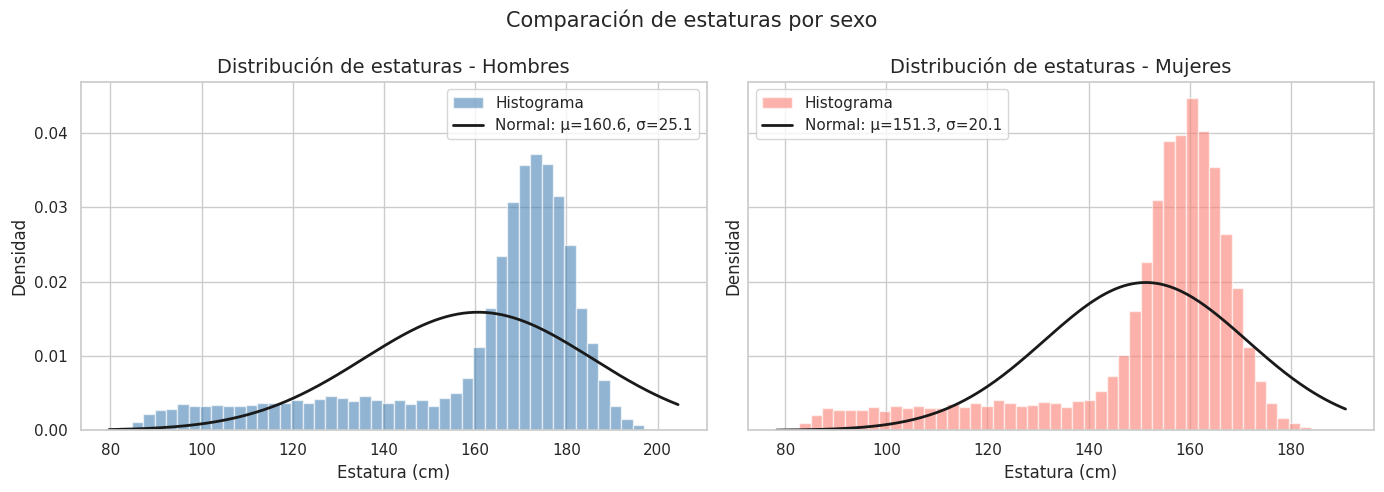

In [ ]:
# Histogramas comparativos con curva normal ajustada (EMV manual por grupo)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colores = {'Hombre': 'steelblue', 'Mujer': 'salmon'}

for ax, (nombre, datos_g, key) in zip(axes,
                                       [('Hombres', hombres, 'Hombre'),
                                        ('Mujeres', mujeres, 'Mujer')]):
    # EMV manual (divide entre n)
    mu_g    = np.sum(datos_g) / len(datos_g)
    sigma_g = np.sqrt(np.sum((datos_g - mu_g)**2) / len(datos_g))

    ax.hist(datos_g, bins=50, density=True, alpha=0.6,
            color=colores[key], label='Histograma')
    x_plot = np.linspace(datos_g.min(), datos_g.max(), 300)
    ax.plot(x_plot, norm.pdf(x_plot, loc=mu_g, scale=sigma_g), 'k-', lw=2,
            label=f'Normal: μ={mu_g:.1f}, σ={sigma_g:.1f}')
    ax.set_title(f'Distribución de estaturas - {nombre}')
    ax.set_xlabel('Estatura (cm)')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Comparación de estaturas por sexo', fontsize=15)
plt.tight_layout()
plt.show()

El boxplot confirma que los hombres tienden a tener una estatura mayor que las mujeres, ya que la mediana de los hombres se encuentra alrededor de 170 cm, mientras que la de las mujeres está cerca de 158 cm.

Además, la caja de los hombres es un poco más amplia, lo que indica una mayor variabilidad en sus estaturas. En ambos grupos aparecen varios valores atípicos, especialmente en las estaturas bajas, aunque también se observan algunos casos altos en mujeres cercanos a los 190 cm.

En general, el gráfico muestra una diferencia clara entre ambos grupos: los hombres presentan estaturas más altas y ligeramente más dispersas, mientras que las mujeres tienen una distribución más concentrada alrededor de su mediana.

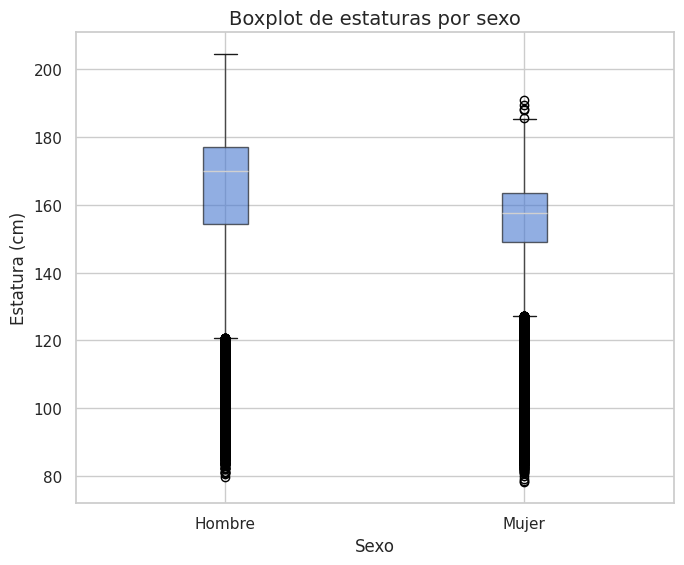

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
df.boxplot(column='Altura', by='Sexo', ax=ax,
           patch_artist=True, boxprops=dict(alpha=0.6))
ax.set_title('Boxplot de estaturas por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('Estatura (cm)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Análisis por grupos de edad

La distribución por grupos de edad muestra que la mayor parte de las personas se concentra en edades adultas y mayores. El grupo con más registros es el de 51 años o más con 13,117 personas, seguido por el grupo de 31 a 50 años con 9,197.

En contraste, los grupos infantiles y adolescentes tienen una menor representación, especialmente el de 0 a 5 años, que es el más pequeño con 4,170 registros. Esto indica que la población analizada está compuesta principalmente por adultos y personas mayores.

En general, los datos reflejan una distribución inclinada hacia edades más avanzadas, lo que podría influir en otros análisis relacionados con características físicas, salud o comportamiento de la población.

In [ ]:
bins_edad   = [0, 5, 12, 18, 30, 50, 130]
labels_edad = ['0-5', '6-12', '13-18', '19-30', '31-50', '51+']

df['Grupo_Edad'] = pd.cut(df['Edad'], bins=bins_edad, labels=labels_edad, right=True)

print('Distribución por grupo de edad:')
print(df['Grupo_Edad'].value_counts().sort_index())

Distribución por grupo de edad:
Grupo_Edad
0-5       4170
6-12      6889
13-18     4746
19-30     5768
31-50     9197
51+      13117
Name: count, dtype: int64


Las estadísticas muestran que la estatura promedio aumenta conforme avanza la edad durante la infancia y adolescencia, alcanzando su punto más alto en el grupo de 19 a 30 años con una media de 168.40 cm. Después de esa etapa, la estatura promedio disminuye ligeramente en los grupos de mayor edad, llegando a 165.39 cm en personas de 51 años o más.

También se observa que los niños de 0 a 5 años tienen la menor media de estatura (101.63 cm), lo cual es consistente con el proceso natural de crecimiento. La dispersión de las estaturas es relativamente similar entre los grupos mayores de 13 años, con desviaciones estándar cercanas a los 10 cm, indicando una variabilidad moderada en las alturas.

Además, los intervalos de confianza al 95% son bastante estrechos en todos los grupos, lo que sugiere que las medias calculadas son estimaciones confiables y representativas de cada rango de edad.

In [ ]:
# Estadísticas por grupo (cálculo manual con la fórmula)
confianza = 0.95
filas = []

for grupo in labels_edad:
    datos_g = df.loc[df['Grupo_Edad'] == grupo, 'Altura'].values
    n_g = len(datos_g)
    gl  = n_g - 1
    media_muestral = np.mean(datos_g)
    s  = np.std(datos_g, ddof=1)              # desviación estándar muestral
    error_est = s / np.sqrt(n_g)              # error estándar de la media

    intervalo = st.t.interval(confianza, gl, loc=media_muestral, scale=error_est)

    filas.append({
        'Grupo_Edad': grupo,
        'n':          n_g,
        'media':      round(media_muestral, 2),
        'desv_est':   round(s, 2),
        'IC_bajo':    round(intervalo[0], 2),
        'IC_alto':    round(intervalo[1], 2),
    })

stats_edad = pd.DataFrame(filas).set_index('Grupo_Edad')
print('Estadísticas de estatura por grupo de edad:')
stats_edad

Estadísticas de estatura por grupo de edad:


,n,media,desv_est,IC_bajo,IC_alto
Grupo_Edad,,,,,
0-5,4170,101.63,9.81,101.34,101.93
6-12,6889,137.19,13.75,136.86,137.51
13-18,4746,165.99,9.31,165.72,166.25
19-30,5768,168.40,9.86,168.14,168.65
31-50,9197,167.89,10.05,167.68,168.09
51+,13117,165.39,10.20,165.22,165.56


El boxplot muestra claramente cómo la estatura cambia conforme aumenta la edad. En los grupos de 0-5 y 6-12 años se observa un incremento notable en la mediana de estatura, reflejando el crecimiento durante la infancia. Posteriormente, en los grupos de 13-18, 19-30 y 31-50 años, las estaturas se estabilizan alrededor de los 165–170 cm, lo que indica que la mayoría de las personas ya alcanzó su altura adulta.

También se aprecia que el grupo de 19-30 años presenta la mediana más alta, mientras que en el grupo de 51+ existe una ligera disminución en la estatura promedio, posiblemente asociada a cambios físicos relacionados con la edad.

Además, todos los grupos presentan algunos valores atípicos tanto altos como bajos, aunque son más visibles en las edades adultas debido a la mayor variabilidad de estaturas en esas categorías. En general, el gráfico refleja un patrón de crecimiento natural: aumento rápido en la niñez y adolescencia, estabilización en la adultez y una leve reducción en edades mayores.

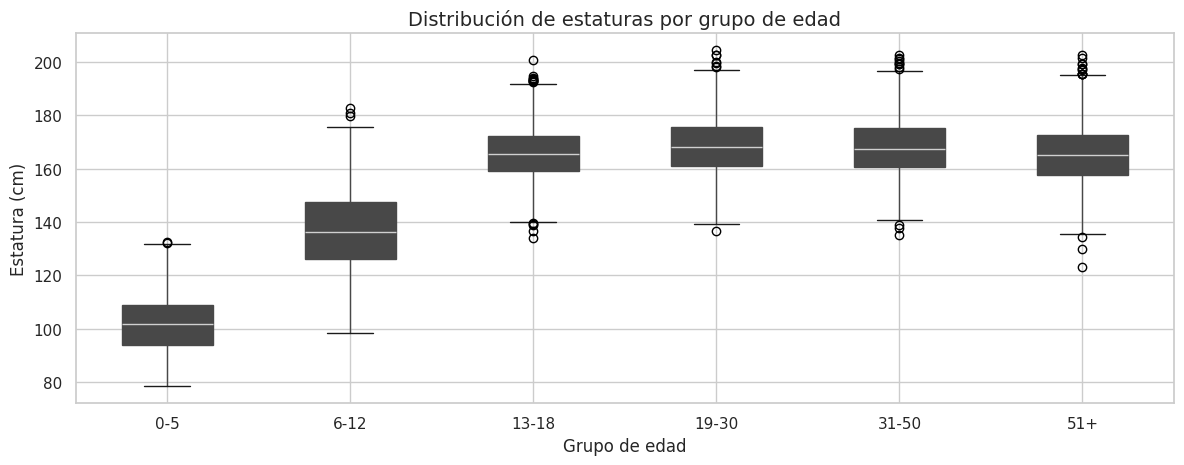

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column='Altura', by='Grupo_Edad', ax=ax, patch_artist=True)
ax.set_title('Distribución de estaturas por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Estatura (cm)')
plt.suptitle('')
plt.tight_layout()
plt.show()